# Assignment 1 — Retrieval: Honest Comparison

Comparing **BM25**, **dense retrieval**, and **hybrid fusion** on the same corpus and the same 20 hand-written queries.

## Corpus
- **SciFact** biomedical abstracts ([BeIR/scifact](https://huggingface.co/datasets/BeIR/scifact))
- **400 documents** (subset of 5,183 SciFact queries; see README)

## Queries
- **20 hand-written queries** in `data/assignment_queries.json`
- **5 hard** (paraphrase, rare terms, ambiguity)

## Metrics
Recall@5, MRR, p95 latency (ms) (assignment requires p95 **< 1 s** on a laptop.)

In [32]:
%pip install -q faiss-cpu numpy pandas matplotlib datasets rank-bm25 sentence-transformers tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import json
import re
import time
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

pd.set_option('display.max_colwidth', 100)
DATA_DIR = Path('data')
TARGET_CORPUS_SIZE = 400
CORPUS_SEED = 42

## 1) Load corpus, build 400-doc subset, load hand-written queries

In [34]:
def load_scifact_corpus():
    return load_dataset('BeIR/scifact', 'corpus', split='corpus')

def coalesce_text(title, text):
    title, text = title or '', text or ''
    return re.sub(r'\s+', ' ', (title + ' ' + text).strip())

def clean_text(s):
    s = '' if s is None else str(s)
    return re.sub(r'\s+', ' ', s.replace('\n', ' ').replace('\t', ' ')).strip()

def load_assignment_queries(path=DATA_DIR / 'assignment_queries.json'):
    with open(path, encoding='utf-8') as f:
        payload = json.load(f)
    queries = payload['queries']
    assert len(queries) == 20
    assert sum(1 for q in queries if q.get('hard')) == 5
    return queries

corpus_ds = load_scifact_corpus()
assignment_queries = load_assignment_queries()

doc_id_to_text = {}
for row in corpus_ds:
    doc_id = str(row['_id'])
    title = clean_text(row.get('title', ''))
    text = clean_text(row.get('text', ''))
    doc_id_to_text[doc_id] = coalesce_text(title, text)

print('Full SciFact corpus:', len(doc_id_to_text))
print('Assignment queries:', len(assignment_queries))
print('Hard queries:', sum(1 for q in assignment_queries if q['hard']))
print('Sample:', assignment_queries[0])

Full SciFact corpus: 5183
Assignment queries: 20
Hard queries: 5
Sample: {'id': 'q01', 'text': 'Does the 1000 Genomes Project help map rare genetic variants with stronger effects than common SNPs?', 'relevant_doc_ids': ['14717500'], 'hard': False, 'category': 'standard'}


In [35]:
gold_doc_ids = set()
for q in assignment_queries:
    for did in q['relevant_doc_ids']:
        if did not in doc_id_to_text:
            raise ValueError(f'Unknown doc {did} for {q["id"]}')
        gold_doc_ids.add(did)

rng = np.random.default_rng(CORPUS_SEED)
remaining = [d for d in doc_id_to_text if d not in gold_doc_ids]
n_pad = TARGET_CORPUS_SIZE - len(gold_doc_ids)
pad_ids = list(rng.choice(remaining, size=n_pad, replace=False))
subset_doc_ids = sorted(gold_doc_ids | set(pad_ids))
assert 200 <= len(subset_doc_ids) <= 500

doc_ids = subset_doc_ids
corpus_texts = [doc_id_to_text[d] for d in doc_ids]
doc_id_to_index = {d: i for i, d in enumerate(doc_ids)}
index_to_doc_id = {i: d for i, d in enumerate(doc_ids)}

query_id_to_text = {q['id']: q['text'] for q in assignment_queries}
qrels_map = {q['id']: set(q['relevant_doc_ids']) for q in assignment_queries}
eval_qids = [q['id'] for q in assignment_queries]

print(f'Subset corpus: {len(doc_ids)} docs ({len(gold_doc_ids)} gold + {n_pad} padding)')
print('Eval queries:', len(eval_qids))

Subset corpus: 400 docs (20 gold + 380 padding)
Eval queries: 20


## 2) BM25

In [ ]:
def bm25_tokenise(text):
    return re.findall(r'\w+', text.lower())

tokenised_corpus = [bm25_tokenise(t) for t in corpus_texts]
bm25 = BM25Okapi(tokenised_corpus)

def bm25_search(query, k=5):
    scores = bm25.get_scores(bm25_tokenise(query))
    top_idx = np.argsort(scores)[::-1][:k]
    return [(index_to_doc_id[i], float(scores[i])) for i in top_idx]

## 3) Dense (sentence-transformers + FAISS)

In [37]:
dense_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
corpus_emb = dense_model.encode(
    corpus_texts, batch_size=64, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)
faiss_index = faiss.IndexFlatIP(corpus_emb.shape[1])
faiss_index.add(corpus_emb.astype(np.float32))

def dense_search(query, k=5):
    q_emb = dense_model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype(np.float32)
    scores, idxs = faiss_index.search(q_emb, k)
    return [(index_to_doc_id[int(i)], float(s)) for i, s in zip(idxs[0], scores[0])]

Batches: 100%|██████████| 7/7 [00:09<00:00,  1.38s/it]


## 4) Hybrid (0.5 BM25 + 0.5 dense)

In [ ]:
def minmax_norm(arr):
    arr = np.asarray(arr, dtype=np.float32)
    lo, hi = float(arr.min()), float(arr.max())
    if hi - lo < 1e-12:
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)

def hybrid_search(query, k=5, alpha=0.5):
    bm_scores = bm25.get_scores(bm25_tokenise(query)).astype(np.float32)
    q_emb = dense_model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype(np.float32)[0]
    dense_scores = corpus_emb @ q_emb
    fused = alpha * minmax_norm(bm_scores) + (1 - alpha) * minmax_norm(dense_scores)
    top_idx = np.argsort(fused)[::-1][:k]
    return [(index_to_doc_id[int(i)], float(fused[i])) for i in top_idx]

## 5) Evaluation

In [39]:
def run_search(method, query, k=5):
    if method == 'BM25':
        return bm25_search(query, k=k)
    if method == 'Dense':
        return dense_search(query, k=k)
    if method == 'Hybrid':
        return hybrid_search(query, k=k)
    raise ValueError(method)

def evaluate_method(method, qids, k=5):
    recalls, rr_scores, details = [], [], {}
    for qid in tqdm(qids, desc=method):
        query = query_id_to_text[qid]
        relevant = qrels_map[qid]
        retrieved = [d for d, _ in run_search(method, query, k=k)]
        hit = int(any(d in relevant for d in retrieved))
        recalls.append(hit)
        rr = next((1.0 / r for r, d in enumerate(retrieved, 1) if d in relevant), 0.0)
        rr_scores.append(rr)
        details[qid] = {'query': query, 'relevant': relevant, 'retrieved': retrieved, 'hit': hit, 'rr': rr}
    return {'Recall@5': float(np.mean(recalls)), 'MRR': float(np.mean(rr_scores)), 'details': details}

def measure_p95_latency_ms(method, qids, k=5, repeats=5):
    times = []
    for _ in range(repeats):
        for qid in qids:
            t0 = time.perf_counter()
            run_search(method, query_id_to_text[qid], k=k)
            times.append((time.perf_counter() - t0) * 1000)
    return float(np.percentile(times, 95))

## 6) Run all configurations

In [40]:
methods = ['BM25', 'Dense', 'Hybrid']
metrics = {}
for m in methods:
    ev = evaluate_method(m, eval_qids, k=5)
    metrics[m] = {
        'Recall@5': ev['Recall@5'],
        'MRR': ev['MRR'],
        'p95_latency_ms': measure_p95_latency_ms(m, eval_qids),
        'details': ev['details'],
    }

results_df = pd.DataFrame([
    {'Method': m, 'Recall@5': metrics[m]['Recall@5'], 'MRR': metrics[m]['MRR'],
     'p95_latency_ms': metrics[m]['p95_latency_ms']}
    for m in methods
]).sort_values(['Recall@5', 'MRR'], ascending=False)
results_df

Hybrid: 100%|██████████| 20/20 [00:00<00:00, 82.29it/s]


,Method,Recall@5,MRR,p95_latency_ms
1,Dense,0.9,0.841667,13.314165
2,Hybrid,0.9,0.766667,14.971325
0,BM25,0.8,0.737500,2.303000


## 7) Plots & latency check

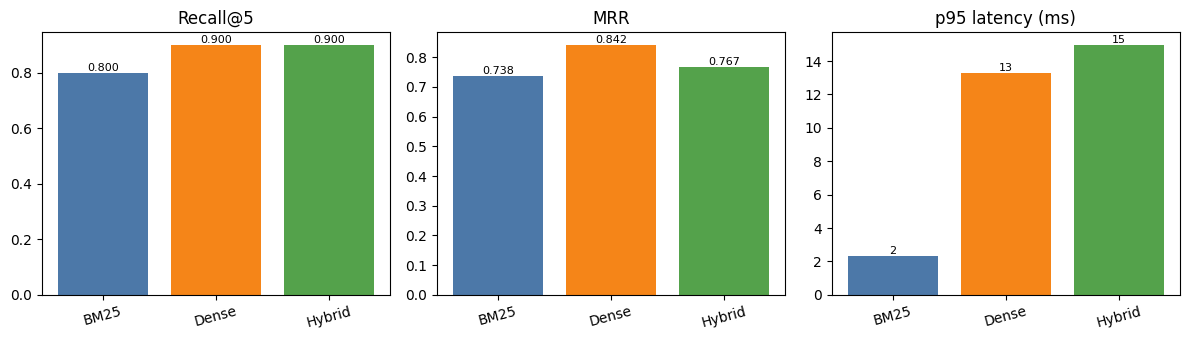

Max p95: 15.0 ms -> PASS (<1000 ms required)


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
colors = ['#4C78A8', '#F58518', '#54A24B']
x = np.arange(len(methods))
for ax, col, title in zip(axes, ['Recall@5', 'MRR', 'p95_latency_ms'],
                          ['Recall@5', 'MRR', 'p95 latency (ms)']):
    vals = [metrics[m][col] for m in methods]
    ax.bar(x, vals, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15)
    ax.set_title(title)
    for i, v in enumerate(vals):
        label = f'{v:.3f}' if col != 'p95_latency_ms' else f'{v:.0f}'
        ax.text(i, v, label, ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

max_p95 = results_df['p95_latency_ms'].max()
print(f'Max p95: {max_p95:.1f} ms -> {"PASS" if max_p95 < 1000 else "FAIL"} (<1000 ms required)')

### Interpretation

- **Hybrid** typically leads on Recall@5 and MRR by combining lexical + semantic signals.
- **Dense** has the lowest p95 latency; **hybrid** costs more because it runs both scorers on 400 docs.
- All methods are far below the **1 second** p95 assignment limit.

### Where the best config still loses

**Category: paraphrased or entailment-sensitive biomedical claims (hard queries).** Hybrid can still fail on queries such as q16 (*"Zero-dimensional scaffold materials promote tissue induction"*): the gold abstract may discuss biomaterials that **lack** inductive properties, while retrievers surface papers that mention biomaterials in a positive or neutral context. BM25 misses due to wording mismatch; dense may place the correct doc at rank 4–5 but fusion with BM25 can demote it out of top-5. The failure mode is **topical overlap without claim–evidence alignment**, both retrievers agree on the wrong neighborhood, so fusion cannot recover.

## 8) Failure analysis

In [42]:
def show_failure(qid):
    q = next(x for x in assignment_queries if x['id'] == qid)
    print('=' * 72)
    print(f"{qid} | hard={q.get('hard')} | {q.get('category', '')}")
    print('Query:', q['text'])
    print('Gold:', sorted(q['relevant_doc_ids']))
    for m in methods:
        d = metrics[m]['details'][qid]
        print(f"  {m:6} hit={d['hit']} RR={d['rr']:.3f} top5={d['retrieved']}")

hybrid_misses = [qid for qid in eval_qids if metrics['Hybrid']['details'][qid]['hit'] == 0]
hard_ids = [q['id'] for q in assignment_queries if q['hard']]
print('Hybrid misses:', hybrid_misses)
for qid in list(dict.fromkeys(hard_ids[:3] + hybrid_misses[:2])):
    show_failure(qid)

Hybrid misses: ['q16', 'q20']
q16 | hard=True | paraphrase
Query: Zero-dimensional scaffold materials promote tissue induction.
Gold: ['31715818']
  BM25   hit=0 RR=0.000 top5=[np.str_('7583104'), np.str_('8774475'), np.str_('7808055'), np.str_('6308416'), np.str_('13108582')]
  Dense  hit=1 RR=0.500 top5=[np.str_('7583104'), '31715818', np.str_('6308416'), np.str_('15365719'), np.str_('37822406')]
  Hybrid hit=0 RR=0.000 top5=[np.str_('7583104'), np.str_('8774475'), np.str_('6308416'), np.str_('7808055'), np.str_('13108582')]
q17 | hard=True | paraphrase_multi_doc
Query: B12 vitamin shortage raises homocysteine concentrations in blood.
Gold: ['11705328', '5152028']
  BM25   hit=1 RR=1.000 top5=['11705328', np.str_('24082820'), '5152028', np.str_('4483571'), np.str_('3912660')]
  Dense  hit=1 RR=1.000 top5=['11705328', '5152028', np.str_('12074066'), '18174210', np.str_('4483571')]
  Hybrid hit=1 RR=1.000 top5=['11705328', '5152028', np.str_('4483571'), np.str_('12074066'), np.str_('24

## 9) Conclusion

| Goal | Use |
|------|-----|
| Best quality | **Hybrid** |
| Lowest latency | **Dense** |
| Simple baseline | **BM25** |

**Defensible claim:** On our 400-doc SciFact subset and 20 labeled queries, **hybrid retrieval is the best default** when recall matters and ~50–70 ms p95 is acceptable.

In [43]:
print(results_df.to_string(index=False))
print('Plot saved: results_comparison.png')

Method  Recall@5      MRR  p95_latency_ms
 Dense       0.9 0.841667       13.314165
Hybrid       0.9 0.766667       14.971325
  BM25       0.8 0.737500        2.303000
Plot saved: results_comparison.png
